# Visualisation of flow cytometry data 

We have taken one flow cytometry dataset from a healthy control sample, from the paper "Longitudinal immune profiling reveals key myeloid signatures associated with COVID-19" (available from https://www.science.org/doi/full/10.1126/sciimmunol.abd6197).

Flow cytometry can be used to quantify the level of cell surface markers on a large number of individual cells in a sample. These markers provide useful information about the cell-type and cell function for many single cells in a sample, e.g. a blood sample. The panel of markers used in this experiment was chosen to help distinguish different immune cells in the blood such as T-cells, monocytes and neutrophils. In the above paper it was shown that the number and activity of these cells differs between patients with mild and severe covid, suggesting how differences in the patient immune response can play an important role in determining the disease severity. 

We use a random subset of 1000 cells in this project, although the full dataset includes around 100,000 cells for each flow cytometry experiment (one patient). 

Code to help carry out this lab is availble in the Iris-InteractivePCA notebook provided. 

### Project aim 1: Use PCA to visualise the data and identify cell-type markers

### 1.1 Adapt the code from the Iris-InteractivePCA notebook to carry out PCA and visualise the data in 2D. 

### 1.2 How many principal components (PCs) are required to explain more than 80% of the variance in the data?

### 1.3 Which PC is most informative for separating T-cells from the other cell-types? Do you think one PC is sufficient to separate T-cells from the rest? 

### 1.4 If we ae to choose one marker (feature) to measure in order to separate the T cells from the others, which would we choose? And why this is a good choice. 

### 1.5 If you wanted to choose one marker (feature) to measure in order to separate monocytes from the others, which would you choose? Explain why this is a good choice. 

### Aim 2; Non-linear dimensionality reduction 

There are alternative non-linear dimensionality reduction methods. Popular ones for single-cell data include tSNE and UMAP but there are also many others available (see https://scikit-learn.org/stable/modules/manifold.html). These methods have many adjustable parameters and you can explore how the results look for different parameter choices. 



Explore how the data visualisation is altered by adjusting the different algorithm parameters (see https://scikit-learn.org/stable/modules/manifold.html#t-distributed-stochastic-neighbor-embedding-t-sne).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import visualisation # some functions defined for this lab
import plotly
import plotly.express as px
import plotly.graph_objs as go

In [2]:
data = pd.read_csv('FlowData1000.csv', index_col=[0])
labels = data.index # The labels give the cell-type for each cell 
N, D = data.shape
print('Cells: %s, Markers: %s'%(N, D))

Cells: 1000, Markers: 21


In [3]:
X = data.values

In [4]:
labels.value_counts()

Neutrophils    427
T cells        342
Monocytes       85
NK cells        56
Eosinophils     38
Basophils       30
B cells         16
DC cells         6
Name: count, dtype: int64

In [5]:
# scale 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
from sklearn.decomposition import PCA

pca = PCA()
scores = pca.fit_transform(X_scaled)
loadings = pca.components_
fracs = pca.explained_variance_ratio_

In [7]:
scores

array([[ 2.95444917e+00,  2.54901311e-01,  2.18829008e+00, ...,
        -8.22127536e-02,  2.48296731e-05,  2.97405883e-05],
       [-3.66631205e+00, -6.94996752e-01, -1.13989919e+00, ...,
         3.57402434e-01, -9.38816892e-05,  3.33845586e-05],
       [ 2.23044789e-01,  3.26990096e+00,  3.22593345e-01, ...,
         2.49573374e-01,  1.27797628e-05, -4.23181310e-05],
       ...,
       [-3.27315731e+00,  1.00541862e+00,  9.48425478e-01, ...,
        -9.89397901e-03,  2.28656177e-04, -1.35060476e-04],
       [-2.94675776e+00, -5.65965687e-01,  6.80986547e-01, ...,
         2.67043452e-01,  6.59394743e-05,  5.18054173e-05],
       [ 5.59217194e-01, -1.74961219e+00, -1.08089804e-01, ...,
         2.79604405e-01,  6.47924846e-05,  1.45478106e-05]],
      shape=(1000, 21))

In [8]:
fracs_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(fracs))],
    'Variance Explained (%)': (fracs * 100).round(2),
    'Cumulative (%)': np.cumsum(fracs)
})
print(fracs_df.to_string(index=False))



  PC  Variance Explained (%)  Cumulative (%)
 PC1                   38.57        0.385714
 PC2                   11.60        0.501675
 PC3                    7.53        0.576987
 PC4                    6.27        0.639638
 PC5                    5.52        0.694873
 PC6                    4.91        0.743940
 PC7                    4.37        0.787686
 PC8                    3.73        0.824995
 PC9                    3.51        0.860076
PC10                    2.76        0.887693
PC11                    2.21        0.909839
PC12                    1.98        0.929605
PC13                    1.79        0.947521
PC14                    1.42        0.961709
PC15                    1.24        0.974089
PC16                    0.98        0.983872
PC17                    0.66        0.990430
PC18                    0.62        0.996664
PC19                    0.33        1.000000
PC20                    0.00        1.000000
PC21                    0.00        1.000000


In [22]:
loadings_df = pd.DataFrame(
    pca.components_[:8].T,
    index=data.columns,
    columns=[f'PC{i+1}' for i in range(8)]
)
print(loadings_df)

             PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
FSC-A   0.282204  0.025935 -0.005680 -0.214451  0.168281 -0.317197  0.331499   
FSC-H   0.255940 -0.025705 -0.058025 -0.211446  0.275165 -0.391535  0.303781   
FSC-W   0.218332  0.212522  0.202337 -0.099625 -0.348909  0.160617  0.244244   
SSC-A   0.337061 -0.005443  0.034746  0.057330 -0.042909  0.070229 -0.079509   
SSC-H   0.335398 -0.024536  0.030911  0.064006 -0.014162  0.047092 -0.112550   
SSC-W   0.120809  0.271166  0.064799 -0.078891 -0.423106  0.350784  0.449169   
CD56    0.101700 -0.133404 -0.581793 -0.185408 -0.020687  0.045115  0.228619   
HLA DR  0.023171  0.543869 -0.020006  0.044441 -0.018194 -0.229565 -0.202414   
CD11c   0.277149 -0.045582 -0.021494  0.277569  0.140516  0.114510  0.014674   
CD14    0.144625  0.406885 -0.022939 -0.257344 -0.042049  0.006858 -0.354897   
CD16    0.292695 -0.205759 -0.038857  0.181570 -0.085119  0.033786 -0.092050   
CD45   -0.271084  0.225313 -0.115132 -0.

In [10]:
scores_df = pd.DataFrame(
    scores,
    index=labels,
    columns=[f'PC{i+1}' for i in range(scores.shape[1])]
)
print(scores_df)

                  PC1       PC2       PC3       PC4       PC5       PC6  \
Neutrophils  2.954449  0.254901  2.188290 -0.646479 -2.060302  1.462869   
T cells     -3.666312 -0.694997 -1.139899  0.414507 -0.376355  0.059450   
Monocytes    0.223045  3.269901  0.322593 -2.366122 -0.564576 -1.098352   
T cells     -3.625222 -0.629525  0.719797 -0.521928  0.851665 -0.016811   
T cells     -2.308650 -0.917192 -3.490780 -0.173956  0.421048 -0.057180   
...               ...       ...       ...       ...       ...       ...   
Neutrophils  2.081291 -0.782777 -0.730624  1.064296  0.139737  0.094227   
B cells     -2.017545  0.920317  1.014020 -0.371154  2.323970  1.970056   
T cells     -3.273157  1.005419  0.948425  0.672563 -0.717057  2.787967   
T cells     -2.946758 -0.565966  0.680987 -1.348026 -0.872239 -1.800287   
Neutrophils  0.559217 -1.749612 -0.108090  1.686476  0.229932  1.490083   

                  PC7       PC8       PC9      PC10  ...      PC12      PC13  \
Neutrophils -0.8042

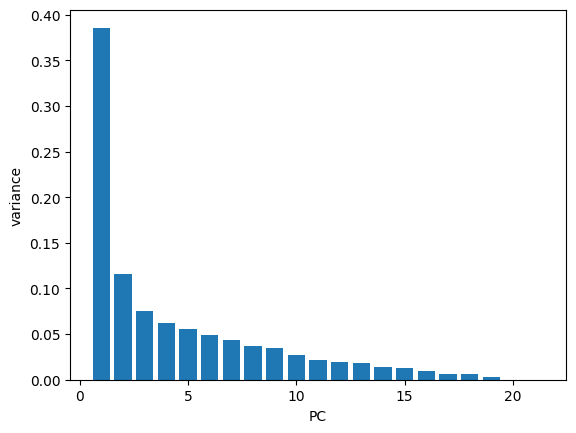

In [11]:
plt.bar(range(1, len(fracs)+1), fracs)
plt.xlabel('PC')
plt.ylabel('variance')
plt.show()

In [12]:
x = np.arange(1,len(fracs)+1) # Create a numpy array from 1 up to the length of the fracs vector
y = np.array(fracs)           # Put the fracs into an numpy array
fig = go.Figure(data=go.Scatter(x=x, y=y, mode = 'lines+markers'))  
fig.update_layout(xaxis_title='Principal component', yaxis_title='Variance explained (fraction)',
                  xaxis = dict(dtick = 1.0, range=[0.5, len(fracs)+0.5]))
fig.show()

In [13]:
x = np.arange(1,len(fracs)+1)
y = np.cumsum(fracs) # Cumulative sum of elements in the fracs array
fig = go.Figure(data=go.Scatter(x=x, y=y, mode='lines+markers'))
fig.update_layout(xaxis_title='Principal component', yaxis_title='Variance explained (cummulative)',
                 xaxis = dict(dtick = 1.0, range=[0.5, len(fracs)+0.5]))
fig.show()

In [14]:
cumsum = np.cumsum(fracs)
n_80 = np.argmax(cumsum >= 0.80) + 1
print(f'PCs for 80% variance: {n_80}')

PCs for 80% variance: 8


In [15]:
fig = px.scatter(scores_df, x='PC1', y='PC2', color=labels, hover_data=['PC1', 'PC2'])
fig.update_traces(mode='markers', marker_line_width=1, marker_size=8)
fig.show()

In [16]:
print(loadings_df['PC1'].abs().sort_values(ascending=False).round(3))

SSC-A     0.337
SSC-H     0.335
CD10      0.298
CD16      0.293
FSC-A     0.282
CD11c     0.277
CD3       0.273
CD45      0.271
CD11b     0.262
FSC-H     0.256
LD        0.232
FSC-W     0.218
CD14      0.145
SSC-W     0.121
CD56      0.102
CD62L     0.074
CD19      0.062
CD1c      0.054
CD24      0.031
HLA DR    0.023
CD123     0.001
Name: PC1, dtype: float64


In [17]:
print(loadings_df['PC2'].abs().sort_values(ascending=False).round(3))

HLA DR    0.544
CD14      0.407
CD1c      0.327
SSC-W     0.271
CD19      0.234
CD45      0.225
FSC-W     0.213
CD16      0.206
CD10      0.186
CD123     0.184
CD24      0.174
CD11b     0.163
CD56      0.133
LD        0.104
CD3       0.084
CD11c     0.046
FSC-A     0.026
FSC-H     0.026
SSC-H     0.025
CD62L     0.011
SSC-A     0.005
Name: PC2, dtype: float64


In [18]:
scores_df = pd.DataFrame(scores, columns=[f'PC{i+1}' for i in range(scores.shape[1])])
fig = px.scatter(scores_df, x='PC1', y='PC2', color=labels, hover_data=['PC1', 'PC2'])
fig.update_traces(mode='markers', marker_line_width=1, marker_size=8)
fig.show()

T cells are separated mainly by CD3 (loading = -0.273 on PC1), which pushes them to the negative/left side of PC1. Neutrophils are separated mainly by SSC-A (0.337), SSC-H (0.335), and CD10 (0.298) on PC1, which pushes them to the positive/right side. The high SSC values reflect neutrophils' high granularity, and CD10 is a known neutrophil surface marker."

In [23]:
# tsne

from sklearn.manifold import TSNE


In [39]:
perplexity = [5, 10, 15, 30, 50, 80]

for n in perplexity:
    tsne = TSNE(
        n_components=2,
        perplexity = n,
        init = 'random',
        max_iter=1000,
        random_state=42,
    )

    tsne_result = tsne.fit_transform(X_scaled)
    tsne_df = pd.DataFrame(tsne_result, columns = ['tsne1', 'tsne2'], index = labels)
    fig = px.scatter(tsne_df, x='tsne1', y='tsne2', color=labels, title = f'tsne (perplexity{n})')
    fig.update_traces(mode='markers', marker_line_width=1, marker_size=8)
    fig.show()

perplexity of 50, gives the cleanest, tightest separation between all 8 cell types. Every group forms a distinct, compact cluster with minimal overlap. T cells (orange) are clearly separate from NK cells (cyan), monocytes (green) are in their own tight group, neutrophils (blue) are on the right, and even the smaller populations like B cells (orange dots), eosinophils (purple), basophils (pink), and DC cells (yellow-green) each have their own visible spot.